In [1]:
from pathlib import Path  # filesystem paths
import pandas as pd  # tabular data handling
import numpy as np  # numerical arrays
import matplotlib.pyplot as plt  # plotting interface
import seaborn as sns  # statistical visualizations

from sklearn.cluster import KMeans  # k-means clustering
from sklearn.metrics import silhouette_score  # silhouette metric for clustering quality
from sklearn.decomposition import PCA  # dimensionality reduction for plotting

In [ ]:
PROJECT_ROOT = Path().resolve().parent # project root (one level up)
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed" # processed data directory
DATA_RAW = PROJECT_ROOT / "data" / "raw" # raw data directory
PLOTS_DIR = PROJECT_ROOT / "reports" / "models" /"kmeans" # clustering plots output
PLOTS_DIR.mkdir(parents=True, exist_ok=True) # ensure output folder exists


In [3]:
def run_kmeans_for(dataset: str = "mat") -> None:  # run full clustering pipeline on chosen dataset
    if dataset not in {"mat", "por"}:  # validate dataset argument
        raise ValueError("dataset must be 'mat' or 'por'")  # enforce valid dataset id

    df = pd.read_csv(DATA_PROCESSED / f"processed_{dataset}.csv")  # load processed feature matrix
    X = df.drop(columns=["G3"])  # remove target label → unsupervised clustering input only

    print(f"[{dataset}] shape of processed feature matrix:", X.shape)  # log feature matrix size

    k_values = range(2, 9)  # range of candidate cluster counts (K)
    sil_scores = []  # store silhouette scores for each K

    for k in k_values:  # iterate over possible cluster numbers
        kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")  # initialize KMeans with K clusters
        labels = kmeans.fit_predict(X)  # perform clustering and obtain cluster assignments
        score = silhouette_score(X, labels)  # compute silhouette score for cluster validity
        sil_scores.append(score)  # record silhouette score for current K

    plt.figure(figsize=(7, 5))  # prepare silhouette plot container
    plt.plot(k_values, sil_scores, marker="o")  # draw silhouette scores vs. K
    plt.title(f"Silhouette Score vs K (student-{dataset})")  # plot title
    plt.xlabel("Number of clusters (K)")  # x-axis label
    plt.ylabel("Silhouette Score")  # y-axis label
    plt.grid(True)  # enable grid for readability
    plt.tight_layout()  # fix layout spacing
    plt.savefig(PLOTS_DIR / f"silhouette_{dataset}.png", dpi=300)  # save silhouette figure
    plt.show()  # display silhouette plot

    best_k = k_values[int(np.argmax(sil_scores))]  # choose K with highest silhouette score
    print(f"[{dataset}] best K according to silhouette:", best_k)  # log best K result

    kmeans = KMeans(n_clusters=best_k, random_state=42, n_init="auto")  # init final KMeans using optimal K
    cluster_labels = kmeans.fit_predict(X)  # compute final cluster assignments
    df["cluster"] = cluster_labels  # append cluster labels to dataframe

    pca = PCA(n_components=2)  # PCA for reducing high dimensions → 2D visualization
    X_pca = pca.fit_transform(X)  # project feature matrix into 2D PCA space

    plt.figure(figsize=(8, 6))  # prepare PCA scatter container
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1],
                    hue=cluster_labels, palette="tab10")  # scatter plot of PCA components
    plt.title(f"KMeans Clusters (k={best_k}) with PCA 2D — student-{dataset}")  # plot title
    plt.tight_layout()  # adjust padding
    plt.savefig(PLOTS_DIR / f"kmeans_pca_{dataset}_k{best_k}.png", dpi=300)  # save PCA scatter
    plt.show()  # display PCA clustering

    cluster_summary = df.groupby("cluster").mean().round(3)  # compute mean feature values per cluster
    print(f"\n[{dataset}] cluster feature means:\n")  # header for summary output
    display(cluster_summary)  # show summary table in notebook

    cluster_summary.to_csv(
        PLOTS_DIR / f"cluster_feature_means_{dataset}.csv"
    )  # export cluster summary as CSV

    raw_path = DATA_RAW / f"student-{dataset}.csv"  # path to raw dataset
    raw_df = pd.read_csv(raw_path, sep=";")  # load raw data for true G3 values

    df["pass"] = (raw_df["G3"] >= 10).astype(int)  # derive pass/fail label from raw G3 scores

    cluster_pass_rate = df.groupby("cluster")["pass"].mean().rename("pass_rate")  # compute pass rate per cluster
    print(f"\n[{dataset}] pass rate per cluster:\n")  # print header
    display(cluster_pass_rate.to_frame())  # show pass/fail distribution per cluster

    cluster_pass_rate.to_csv(
        PLOTS_DIR / f"cluster_pass_rate_{dataset}.csv"
    )  # export pass-rate table for reporting

    plt.figure(figsize=(10, 6))  # prepare heatmap figure
    sns.heatmap(cluster_summary, cmap="viridis")  # plot cluster-wise feature averages heatmap
    plt.title(f"Cluster Feature Means Heatmap (student-{dataset})")  # heatmap title
    plt.tight_layout()  # adjust layout spacing
    plt.savefig(PLOTS_DIR / f"cluster_heatmap_{dataset}.png", dpi=300)  # save heatmap
    plt.show()  # display heatmap

[por] shape of processed feature matrix: (649, 46)


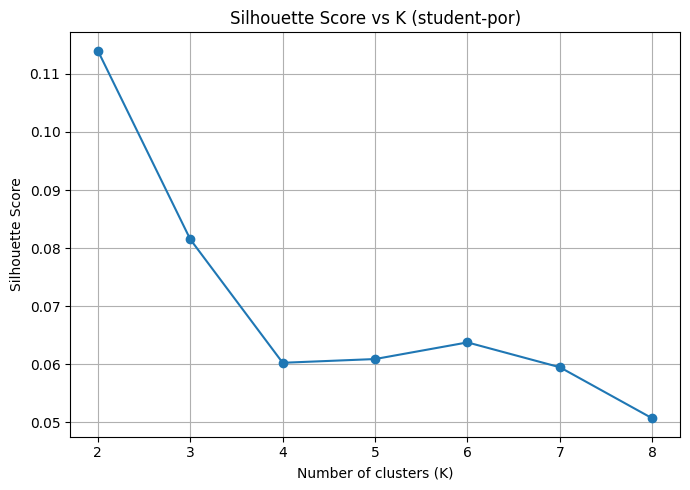

[por] best K according to silhouette: 2


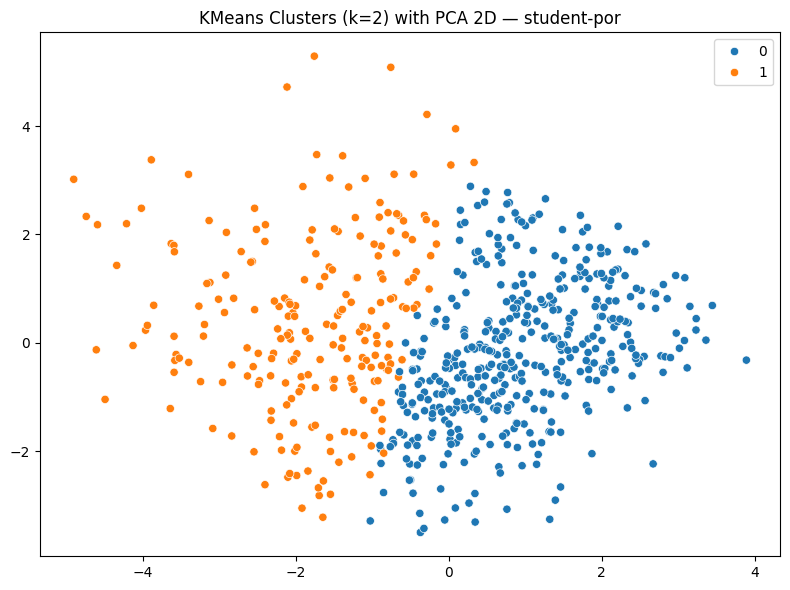


[por] cluster feature means:



,sex_M,address_U,famsize_LE3,Pstatus_T,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.336,0.773,0.294,0.864,0.119,0.638,0.054,0.488,0.822,0.974,...,0.036,-0.264,-0.209,-0.354,-0.373,-0.103,-0.321,0.458,0.510,0.581
1,0.552,0.548,0.299,0.900,0.077,0.566,0.072,0.480,0.765,0.738,...,-0.115,0.349,0.606,0.756,0.699,0.161,-0.132,-0.453,-0.318,-0.168



[por] pass rate per cluster:



,pass_rate
cluster,
0,0.946262
1,0.651584


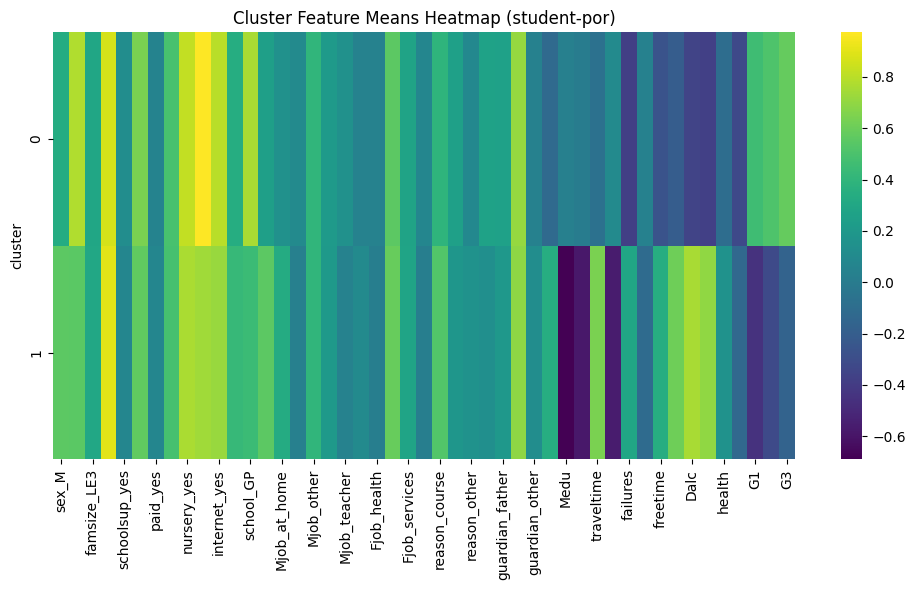

In [4]:
run_kmeans_for("por") #run train function for por file

[mat] shape of processed feature matrix: (395, 46)


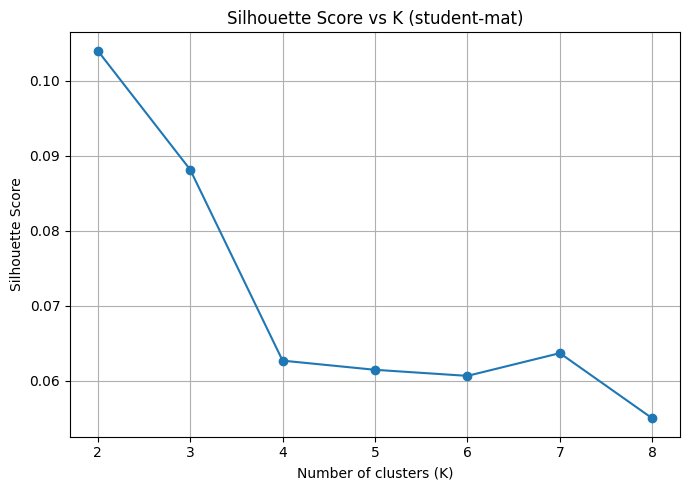

[mat] best K according to silhouette: 2


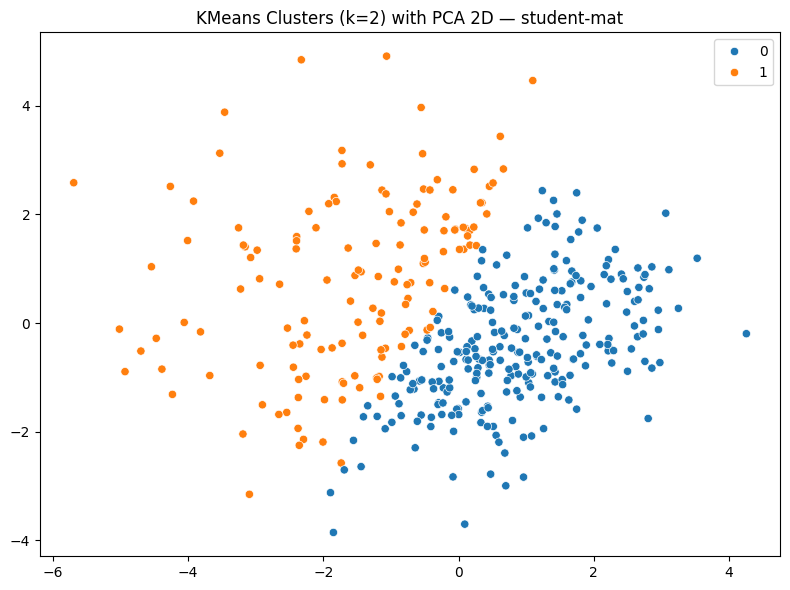


[mat] cluster feature means:



,sex_M,address_U,famsize_LE3,Pstatus_T,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.380,0.824,0.247,0.894,0.133,0.624,0.49,0.522,0.839,0.984,...,0.106,-0.201,-0.334,-0.426,-0.495,-0.123,-0.113,0.274,0.270,0.230
1,0.643,0.693,0.364,0.900,0.121,0.593,0.40,0.486,0.714,0.886,...,-0.193,0.365,0.609,0.776,0.901,0.223,0.206,-0.498,-0.492,-0.419



[mat] pass rate per cluster:



,pass_rate
cluster,
0,0.772549
1,0.485714


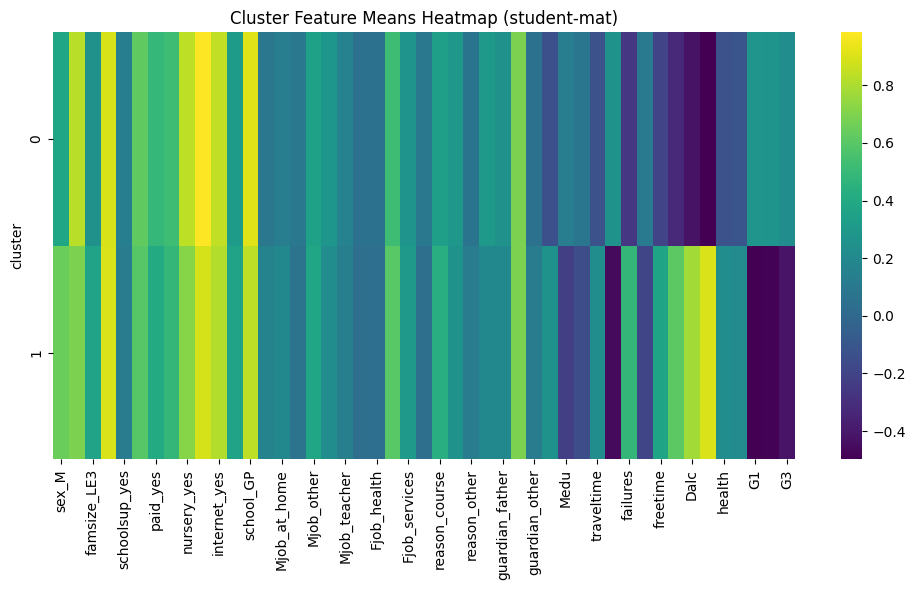

In [5]:
run_kmeans_for("mat")  #run train function for mat file